In [7]:
import cv2
import os
import pandas as pd
import numpy as np

# CONFIG
IMAGE_DIR = '/home/demo-user/Downloads/LoTSS files/GANS+PROD/Gan iter 3'
OUTPUT_CSV = '/home/demo-user/Downloads/LoTSS files/gan_iter3_annotations.csv'
PADDING = 20

annotations = []
skipped = 0

for filename in os.listdir(IMAGE_DIR):
    if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue

    img_path = os.path.join(IMAGE_DIR, filename)
    img = cv2.imread(img_path)

    if img is None:
        print(f"Could not read: {filename}")
        skipped += 1
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    H, W = gray.shape

    # Enhance contrast
    gray_eq = cv2.equalizeHist(gray)

    # Threshold - keep only bright regions
    _, thresh = cv2.threshold(gray_eq, 200, 255, cv2.THRESH_BINARY)

    # Clean noise
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    clean = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    cx_img, cy_img = W // 2, H // 2

    if not contours:
        # Fallback: label central 30% of image
        margin_x = int(W * 0.35)
        margin_y = int(H * 0.35)
        annotations.append([filename, margin_x, margin_y, W - margin_x, H - margin_y, "galaxy"])
        continue

    # Pick contour closest to image centre
    best = min(contours, key=lambda c: (
        (cv2.moments(c)['m10'] / (cv2.moments(c)['m00'] + 1e-5) - cx_img) ** 2 +
        (cv2.moments(c)['m01'] / (cv2.moments(c)['m00'] + 1e-5) - cy_img) ** 2
    ))

    x, y, w, h = cv2.boundingRect(best)

    # Add padding, clamp to image bounds
    xmin = max(0, x - PADDING)
    ymin = max(0, y - PADDING)
    xmax = min(W, x + w + PADDING)
    ymax = min(H, y + h + PADDING)

    # Reject implausibly large boxes (> 80% of image = noise, use fallback)
    if (xmax - xmin) > 0.8 * W or (ymax - ymin) > 0.8 * H:
        margin_x = int(W * 0.35)
        margin_y = int(H * 0.35)
        annotations.append([filename, margin_x, margin_y, W - margin_x, H - margin_y, "galaxy"])
        continue

    annotations.append([filename, xmin, ymin, xmax, ymax, "galaxy"])

df = pd.DataFrame(annotations, columns=["filename", "xmin", "ymin", "xmax", "ymax", "class"])
df.to_csv(OUTPUT_CSV, index=False)

print(f"Annotated {len(df)} GAN images -> {OUTPUT_CSV}")
print(f"Skipped {skipped} unreadable files")

✅ Annotated 4000 GAN images → /home/demo-user/Downloads/LoTSS files/gan_iter3_annotations.csv
⚠️ Skipped 0 unreadable files


Using image: /home/demo-user/Downloads/LoTSS files/GAN DATA/test49_region_19_z0.10.jpg
Contours found: 853


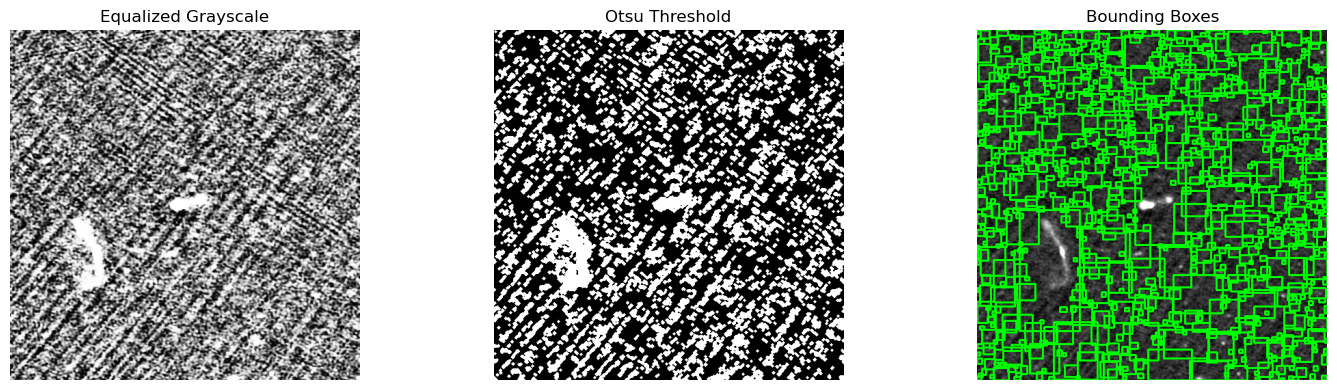

In [179]:
import cv2
import os
import matplotlib.pyplot as plt

# Path to your directory
IMAGE_DIR = '/home/demo-user/Downloads/LoTSS files/GAN DATA'

# Get first valid image file
image_files = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
if not image_files:
    raise FileNotFoundError("No images found in directory.")

img_path = os.path.join(IMAGE_DIR, image_files[0])
print(f"Using image: {img_path}")

# Load and process
img = cv2.imread(img_path)
if img is None:
    raise ValueError(f"Could not load image at {img_path}")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 1: Histogram equalization
gray_eq = cv2.equalizeHist(gray)

# Step 2: Otsu's thresholding
_, thresh = cv2.threshold(gray_eq, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Step 3: Morphological cleaning
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Step 4: Contour detection
vis_img = img.copy()
contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"Contours found: {len(contours)}")

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    area = w * h
    if area >= 10:
        cv2.rectangle(vis_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

# Display images
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.title("Equalized Grayscale")
plt.imshow(gray_eq, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Otsu Threshold")
plt.imshow(clean, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Bounding Boxes")
plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()


Randomly selected image: /home/demo-user/Downloads/LoTSS files/RealImages/test14_region_6_z0.10.jpg
Bounding box: (179, 221) to (313, 325)


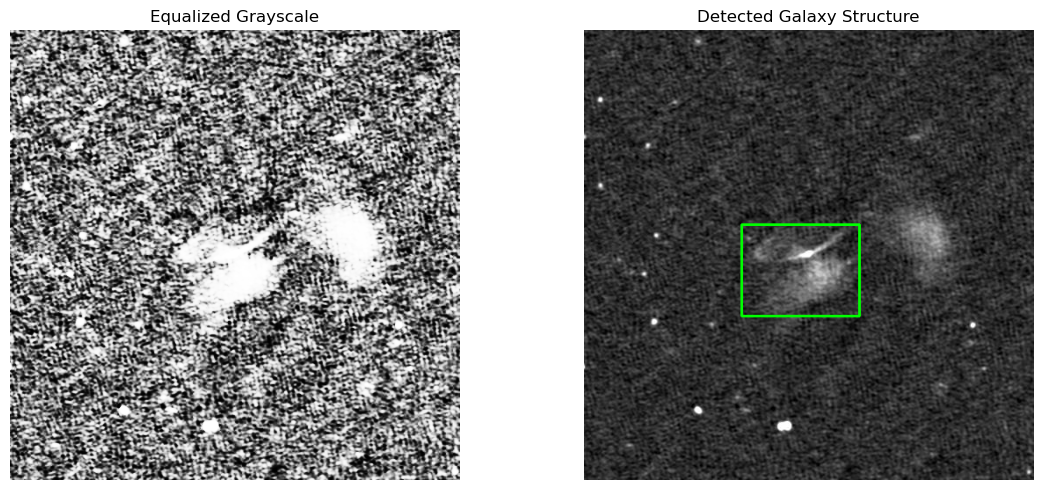

In [292]:
import cv2
import os
import matplotlib.pyplot as plt
import random
import numpy as np

# Folder containing images
IMAGE_DIR = "/home/demo-user/Downloads/LoTSS files/RealImages"

# Get image list
image_files = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
if not image_files:
    raise FileNotFoundError("No image files found in directory.")

# Select a random image
img_filename = random.choice(image_files)
img_path = os.path.join(IMAGE_DIR, img_filename)
print("Randomly selected image:", img_path)

# Load image
img = cv2.imread(img_path)
if img is None:
    raise ValueError(f"Could not load image: {img_path}")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_eq = cv2.equalizeHist(gray)

# Threshold to binary
_, thresh = cv2.threshold(gray_eq, 220, 255, cv2.THRESH_BINARY)

# Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Find largest or most central contour
vis_box = img.copy()
h, w = gray.shape
cx, cy = w // 2, h // 2

if contours:
    # Sort contours by proximity to image center
    contours = sorted(contours, key=lambda cnt: cv2.pointPolygonTest(cnt, (cx, cy), True)**2)
    largest = contours[0]

    # Get bounding box
    x, y, bw, bh = cv2.boundingRect(largest)
    xmin, ymin, xmax, ymax = x, y, x + bw, y + bh
    print(f"Bounding box: ({xmin}, {ymin}) to ({xmax}, {ymax})")

    # Draw rectangle
    cv2.rectangle(vis_box, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
else:
    print("⚠️ No contours found.")

# Show images
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Equalized Grayscale")
plt.imshow(gray_eq, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Detected Galaxy Structure")
plt.imshow(cv2.cvtColor(vis_box, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()


In [187]:
import cv2
import os
import pandas as pd

# CONFIG
IMAGE_DIR = '/home/demo-user/Downloads/LoTSS files/GANS+PROD/Gan iter 1'
OUTPUT_CSV = "/home/demo-user/Downloads/all_annotations.csv"


# Blob detector setup
params = cv2.SimpleBlobDetector_Params()
params.filterByColor = True
params.blobColor = 255  # Bright blobs only
params.filterByArea = False
params.filterByCircularity = False
params.filterByConvexity = False
params.filterByInertia = False
detector = cv2.SimpleBlobDetector_create(params)

# Store all annotations
annotations = []

image_files = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

for filename in image_files:
    img_path = os.path.join(IMAGE_DIR, filename)
    img = cv2.imread(img_path)
    if img is None:
        print(f"⚠️ Could not read {filename}, skipping.")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_eq = cv2.equalizeHist(gray)

    # Detect blobs
    keypoints = detector.detect(gray_eq)

    # Get central one only
    h, w = gray.shape
    cx, cy = w // 2, h // 2
    if keypoints:
        keypoints = sorted(keypoints, key=lambda kp: (kp.pt[0] - cx)**2 + (kp.pt[1] - cy)**2)
        kp = keypoints[0]
        r = kp.size / 2
        x, y = kp.pt
        xmin = int(x - r)
        ymin = int(y - r)
        xmax = int(x + r)
        ymax = int(y + r)
        annotations.append([filename, xmin, ymin, xmax, ymax, "galaxy"])
    else:
        print(f"❌ No blob found in {filename}")

# Save to CSV
df = pd.DataFrame(annotations, columns=["filename", "xmin", "ymin", "xmax", "ymax", "class"])
df.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Saved {len(df)} annotations to {OUTPUT_CSV}")


❌ No blob found in generated_epoch1500_img_150.png
❌ No blob found in generated_epoch1500_img_1208.png


KeyboardInterrupt: 

In [294]:
import cv2
import os
import pandas as pd
import numpy as np

# Config
IMAGE_DIR = "/home/demo-user/Downloads/LoTSS files/RealImages"
OUTPUT_CSV = "/home/demo-user/Downloads/real_annotations.csv"

# Get image list
image_files = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
if not image_files:
    raise FileNotFoundError("No image files found in directory.")

annotations = []

for filename in image_files:
    img_path = os.path.join(IMAGE_DIR, filename)
    img = cv2.imread(img_path)
    if img is None:
        print(f"❌ Skipping unreadable image: {filename}")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_eq = cv2.equalizeHist(gray)

    # Threshold to binary
    _, thresh = cv2.threshold(gray_eq, 220, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    h, w = gray.shape
    cx, cy = w // 2, h // 2

    if contours:
        # Sort by proximity to image center
        contours = sorted(contours, key=lambda cnt: cv2.pointPolygonTest(cnt, (cx, cy), True)**2)
        largest = contours[0]

        # Bounding box
        x, y, bw, bh = cv2.boundingRect(largest)
        xmin, ymin, xmax, ymax = x, y, x + bw, y + bh

        annotations.append([filename, xmin, ymin, xmax, ymax, "galaxy"])
    else:
        print(f"⚠️ No contours found in: {filename}")

# Save to CSV
df = pd.DataFrame(annotations, columns=["filename", "xmin", "ymin", "xmax", "ymax", "class"])
df.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Annotated {len(df)} images. Saved to: {OUTPUT_CSV}")


✅ Annotated 247 images. Saved to: /home/demo-user/Downloads/real_annotations.csv


In [298]:
import pandas as pd

gan_csv = pd.read_csv("/home/demo-user/Downloads/all_annotations.csv")
real_csv = pd.read_csv("/home/demo-user/Downloads/real_annotations.csv")

merged = pd.concat([gan_csv, real_csv], ignore_index=True)
merged.to_csv("/home/demo-user/Downloads/combined_annotations.csv", index=False)
